### Zadanie:

A. Wybrać trzy metody poszukiwania pierwiastków: 

* wykorzystującą przedział i zmianę znaku, 
* wykorzystującą pochodną, 
* wykorzystującą przybliżenie pochodnej

    1. Każdą z trzech wybranych metod przetestować (ilość iteracji, ilość wywołań funkcji) na sześciu wybranych  funkcjach ze zbioru http://people.sc.fsu.edu/~jburkardt/py_src/test_zero/test_zero.html Wyniki przedstawić w formie tabelki. <b>Pamiętać o sprawdzeniu czy wynik jest poprawny poprzez obliczenie wartości funkcji dla znalezionego pierwiastka !</b> (3 pkt)

    2. Zademonstrować wybrany, ciekawy przykład trudnej funkcji z p.1 i działania metod na niej. (1 pkt)

    3. Dla każdej z wybranych metod zademonstrować i wyjaśnić po jednym  przykładzie, dla którego nie działają (można na podstawie p.1 lub wymyślić własny)(1 pkt)

B. Narysować <a href="https://pl.wikipedia.org/wiki/Wst%C4%99ga_Newtona"> wstegę Newtona </a> i objaśnić, w jaki sposób powstała i jaki jest jej związek z metodą Newtona do znajdowania pierwiastków. Sposób i język - dowolny. (1 pkt)

In [61]:
# Wprowadzenie: funkcja find_zero dobiera odpowiedni algorytm w zależności od sposobu wywołania.
using Roots, Plots, ForwardDiff, DataFrames

In [62]:
# 6 wybranych funkcji
f1(x) = sin(x) - x/2
f2(x) = x^3
f3(x) = cos(x) - x
f4(x) = exp(x) - 2 - 1/(10 * x)^2 + 2/(100 * x)^3
epsilon = 0.00001
f5(x) = (16.0 - x^4)/(16.0 * x^4 + epsilon) # the Pinhead
f6(x) = 20.0 * x/(100.0 * x * x + 1.0) # the Repeller

f6 (generic function with 1 method)

In [63]:
# DataFrame do wyników
results = DataFrame(
    Function = String[],
    Method = String[],
    Root = Float64[],
    Iterations = Int[],
    Function_Evals = Int[],
    Verification = Float64[],
    Is_Correct = Bool[]
)

Row,Function,Method,Root,Iterations,Function_Evals,Verification,Is_Correct
,String,String,Float64,Int64,Int64,Float64,Bool


In [64]:
functions = [f1, f2, f3, f4, f5, f6]
fnames = ["f1", "f2", "f3", "f4", "f5", "f6"]
intervals = [(1.0, 2.0), (-1.0, 1.0), (0.0, 1.0), (0.001, 2.0), (1.0, 2.0), (-1.0, 1.0)]  

# Funkcja do obliczania pochodnej
D(f) = x->ForwardDiff.derivative(f, float(x))

for (i, f) in enumerate(functions)
    # Metoda Bisekcji
    try
        tracker = Roots.Tracks()
        x = find_zero(f, intervals[i], Bisection(), tracks=tracker)
        push!(results, (fnames[i], "Bisection", x, tracker.steps, tracker.fncalls, f(x), abs(f(x)) < 1e-10))
    catch e
        push!(results, (fnames[i], "Bisection", NaN, 0, 0, NaN, false))
        println("Bisection failed for $(fnames[i]): $e")
    end

    # Metoda Newtona
    try
        tracker = Roots.Tracks()
        x0 = (intervals[i][1] + intervals[i][2])/2  
        x = find_zero((f, D(f)), x0, Roots.Newton(), tracks=tracker)
        push!(results, (fnames[i], "Newton",  x, tracker.steps, tracker.fncalls, f(x), abs(f(x)) < 1e-10))
    catch e
        push!(results, (fnames[i], "Newton", NaN, 0, 0, NaN, false))
        println("Newton failed for $(fnames[i]): $e")
    end

    # Metoda Steffensena (przybliżenie pochodnej)
    try
        tracker = Roots.Tracks()
        x0 = (intervals[i][1] + intervals[i][2])/2  
        x = find_zero(f, x0, Order2(), tracks=tracker)
        push!(results, (fnames[i], "Steffensen", x, tracker.steps, tracker.fncalls, f(x), abs(f(x)) < 1e-10))
    catch e
        push!(results, (fnames[i], "Steffensen", NaN, 0, 0, NaN, false))
        println("Steffensen failed for $(fnames[i]): $e")
    end
end

# Wyświetlenie wyników
println(results)

18×7 DataFrame
 Row │ Function  Method      Root      Iterations  Function_Evals  Verification  Is_Correct 
     │ String    String      Float64   Int64       Int64           Float64       Bool       
─────┼──────────────────────────────────────────────────────────────────────────────────────
   1 │ f1        Bisection   1.89549           49              52   0.0                true
   2 │ f1        Newton      1.89549            5              10  -2.22045e-16        true
   3 │ f1        Steffensen  1.89549            6              10   0.0                true
   4 │ f2        Bisection   0.0                0               3   0.0                true
   5 │ f2        Newton      0.0                1               2   0.0                true
   6 │ f2        Steffensen  0.0                0               2   0.0                true
   7 │ f3        Bisection   0.739085          60              63   0.0                true
   8 │ f3        Newton      0.739085           4             


--- Analiza trudnego przypadku: f4 ---


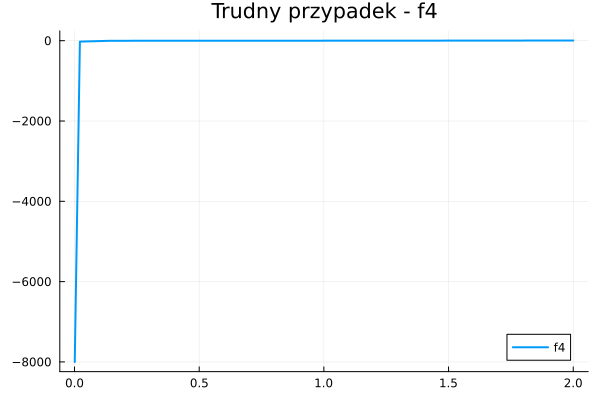

In [65]:
# Trudny przypadek: f4
println("\n--- Analiza trudnego przypadku: f4 ---")

plot(f4, 0.001, 2.0, label="f4", title="Trudny przypadek - f4", lw=2)

In [66]:
# Spróbujmy użyć każdej z metod i wypisać wynik
x0 = (0.001 + 2.0)/2

try
    println("Bisekcja:")
    x = find_zero(f4, (0.001, 2.0), Bisection())
    println("x = $x, f(x) = $(f4(x))")
catch e
    println("Bisekcja zawiodła: $e")
end

try
    println("Newton:")
    x = find_zero((f4, D(f4)), x0, Roots.Newton())
    println("x = $x, f(x) = $(f4(x))")
catch e
    println("Newton zawiódł: $e")
end

try
    println("Steffensen:")
    x = find_zero(f4, x0, Order2())
    println("x = $x, f(x) = $(f4(x))")
catch e
    println("Steffensen zawiódł: $e")
end

Bisekcja:
x = 0.7032048403631358, f(x) = 1.7390094626899139e-16
Newton:
x = 0.7032048403631358, f(x) = 1.7390094626899139e-16
Steffensen:
x = 0.7032048403631358, f(x) = 1.7390094626899139e-16


In [74]:
# Przykład porażki bisekcji: brak zmiany znaku na krańcach przedziału
g1(x) = x^2 - 1
println("\n--- BISEKCJA: Nie działa ---")
try
    x = find_zero(g1, (2.0, 5.0), Bisection())
    println("x = $x")
catch e
    println("Bisekcja zawiodła: — $e")
end


--- BISEKCJA: Nie działa ---
Bisekcja zawiodła: — ArgumentError("The interval [a,b] is not a bracketing interval.\nYou need f(a) and f(b) to have different signs (f(a) * f(b) < 0).\nConsider a different bracket or try fzero(f, c) with an initial guess c.\n\n")


In [82]:
# Przykład porażki Newtona: prawie pionowa pochodna w 0
g2(x) = x^(1/3)
println("\n--- NEWTON: Nie działa ---")
try
    x = find_zero((g2, D(g2)), 0.1, Roots.Newton())
    println("x = $x")
catch e
    println("Newton zawiódł: — $e")
end


--- NEWTON: Nie działa ---
Newton zawiódł: — DomainError(-0.20000000000000004, "Exponentiation yielding a complex result requires a complex argument.\nReplace x^y with (x+0im)^y, Complex(x)^y, or similar.")


In [83]:
# Przykład porażki Steffensena: funkcja nieciągła
g3(x) = x/(x-1) - 1
println("\n--- STEFFENSEN: Nie działa ---")
try
    x = find_zero(g3, 0.0, Order2()) 
    println("x = $x")
catch e
    println("Steffensen zawiódł: — $e")
end


--- STEFFENSEN: Nie działa ---
Steffensen zawiódł: — Roots.ConvergenceFailed("Algorithm failed to converge")


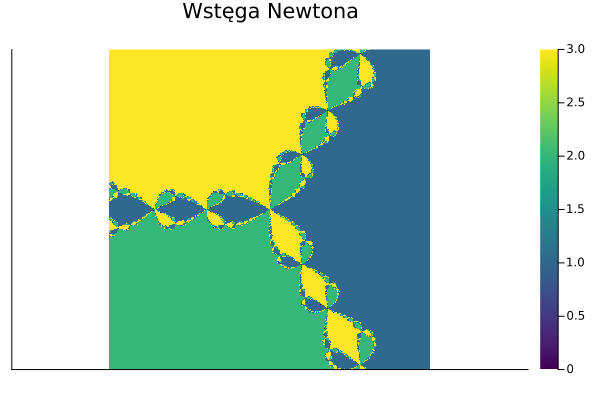

In [86]:
# Wstęga Newtona

# Funkcja i pochodna
p(z) = z^3 - 1
Dp(z) = 3z^2

# Metoda Newtona
function newton(z)
    for i in 1:30
        z -= p(z)/Dp(z)
    end
    return z
end

# Określ, do którego pierwiastka zbiega
function root_id(z)
    roots = [1 + 0im, -0.5 + sqrt(3)/2im, -0.5 - sqrt(3)/2im]
    for i in 1:3
        if abs(z - roots[i]) < 1e-3
            return i
        end
    end
    return 0
end

# Tworzenie fraktala
function draw_fractal()
    res = 400
    xs = range(-2, 2, length=res)
    ys = range(-2, 2, length=res)
    img = zeros(UInt8, res, res)

    for i in 1:res, j in 1:res
        z0 = xs[j] + ys[i]*im
        z = newton(z0)
        img[i, j] = root_id(z)
    end

    heatmap(xs, ys, img, title="Wstęga Newtona", color=:viridis, axis=nothing, aspect_ratio=:equal)
end

draw_fractal()
